# Audio Declipping
   
*   Mykola Liashuha
*   Jose Gonzalez Lopez

# Introduction
The audio declipping problem is a type of inverse problem is signal processig in where we can use the iterative thresholding algorithms and the principle of social sparsity to solve it. Our main objective will be to comment the results given in [1] in which we will base our audio declipping problem and solution by using a toy audio example. Later, we will move into the discussion of the algorithm itself, analyse it carefully and try to find any strenghts, weaknesses or parameter limitations that the solution may have for other equivalent inverse problems.

In [1]:
import numpy as np
import scipy #Library for signal analysis
import matplotlib.pyplot as plt #Plot
import numpy as np #Operations
import cv2 #Read images and do operations
import IPython.display as ipd
import numpy.random #For generating noise
import copy #For copying the variable
import math #Math operations

from numpy import linalg #More math

from scipy import signal #Signal handling
from scipy.io import wavfile #Read wavfiles
from scipy.signal import welch,stft,istft #Get power density estimated, short fourier transform
from scipy.signal import convolve2d #Convolve operator

#Libraries for computing the gabor windows
from ltfatpy.gabor.gabwin import gabwin
from ltfatpy.gabor.gabtight import gabtight
from ltfatpy.gabor.dgtreal import dgtreal
from ltfatpy.gabor.idgtreal import idgtreal

from tqdm import tqdm #For progress bars


# Auxiliar Variables
This cell controls which audio file can be studied, and the main declipping parameters

# Auxiliar functions

In [2]:
'''
Read the audio file properly, there are problems if we do not cast to double
wavfile_name: the path to the wavfile
'''
def read_file_PROPERLY(wavfile_name):
    samplerate_music, data_music = wavfile.read(wavfile_name) #Read the file
    data_music=data_music.astype(np.double)/2**15 #Make values correct
    return samplerate_music,data_music

In [3]:
'''
Clip data with a certain threshold, returns the clipped samples and the particular masks 
that applied to the original data returns those cipped samples
'''
def clip_audio(data, thresh):
    data = data.copy()
    masks = {}
    thr_max = thresh
    thr_min = -thresh
    mask_h  = data > thr_max
    mask_l  = data < thr_min
    mask_r = ~(mask_h | mask_l)
    masks['Mh'] = mask_h
    masks['Ml'] = mask_l
    masks['Mr'] = mask_r
    data[mask_h] = thr_max
    data[mask_l] = thr_min
    return data, masks

In [4]:
'''
Forward and inverse operations using the gabor window method
'''
def analysis(x):
    return dgtreal(x,g[0],a,M)[0]
    
def synthesis(x):
    return idgtreal(x,g[0],a,M,Ls)[0]

In [5]:
'''
Calculate the snr value between two signals
'''
def sdr (u, v):
    snr_val = 20*np.log10(np.linalg.norm(u)/np.linalg.norm(u-v))
    return snr_val

In [6]:
'''
Smoothes the data for generating persistent shrinkage masks
'''
def persistent_shrinkage_masks(G, neigh, center):
    m,n = G.shape
    MM, NN = neigh.shape
    c1 = center[0]
    c2 = center[1]
    cc1 = int(np.ceil(MM/2))
    cc2 = int(np.ceil(NN/2))
    neigh = neigh/np.linalg.norm(neigh, 1)

    X2 = np.zeros((m+MM, n+NN))
    X2[c1:m+c1, c2: n+c2] = np.abs(G)**2
    X2[:, :c2] =  np.fliplr(X2[:, c2:2*(c2)])
    X2[:, n+c2:] = np.fliplr(X2[:, n - NN +2*c2: n+c2])
    X2[:c1, :] = np.flipud(X2[c1:2*c1, :]) 
    X2[m+c1:, :] = np.flipud(X2[m-MM + 2*c1: m+c1, :])
    
    X2 = convolve2d( X2, neigh, 'same')
    
    W = X2[cc1 : m + cc1, cc2 : n + cc2]
    W = np.sqrt(W)
    return W

In [7]:
def thresholding(G, neigh_, center_, lambda_, expo_):

    W = persistent_shrinkage_masks(G, neigh_, center_)

    # lasso thresholding
    TF = lambda_/W

    # shrinkage
    TF[np.isinf(TF)] = 0
    Gs = 1 - np.power(TF, expo_)
    GGs = Gs*(Gs>0)
    

    Gs = G*GGs

    return Gs

# Data
We will be using the music signal as the previous notebooks. We will do some basic data exploration to listen to the melody and see the data plotted in 2D.

In [8]:
#Audio file
audio_file = 'music.wav'

fs, data = read_file_PROPERLY(audio_file)
Ls = len(data)
ipd.Audio(data, rate=fs)

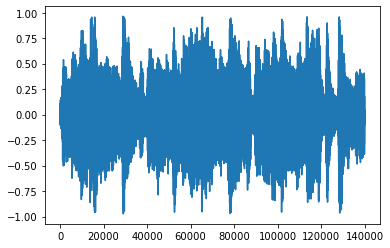

In [9]:
plt.plot(data)

# Audio Clipping

Clipping in general means a  particular inverse problem in which if a signal’s amplitude exceeds a certain threshold it will be trimmed. For clipped signals, compared to other problems as inpaiting, we have "some" information of the missing values. The resulting signal truncation usually leads to a very unpleasant digital distortion. [1] We will first then generate the problem by reading the music file and then trimming it to a certain threshold. 

In [10]:
wtype = 'hann' 
w = 8192 #1024
a = int(w / 4)
M = 2*w

verbose = True

In [11]:
#Creating shrinkage
# # L
# neigh=np.ones((1,1))
# center=np.array([1,1])
# expo=1

# WGL
neigh=np.ones((3,7))
center=np.array([2,4])
expo=1

# # EW
# neigh= np.ones((1,1))
# center=np.array([1, 1])
# expo=2


# # PEW
# neigh=np.ones((3,7))
# center=np.array([2,4])
# expo=2

In [12]:
theta = 0.4
data_clipped, masks = clip_audio(data, theta)
ipd.Audio(data_clipped, rate=fs)

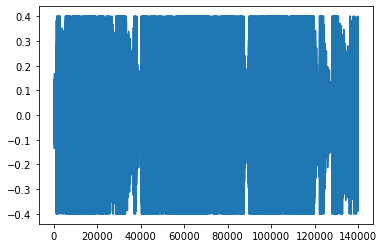

In [13]:
plt.plot(data_clipped)

As we can see in the image and hear in the audio, the audio file has been corrupted. Our objective will be to retrieve the original audio by doing some audio declipping.

# Audio Declipping
Based on the assumption of sparse synthesis coefficients of the original signal, the declipping problem can be modeled by

\begin{equation}
α = \text{argmin}_{α}‖α‖_{0} \text{ s.t. } ‖y^{r} − M^{r}Φα‖^{2}_{2} ≤ \epsilon 
\end{equation}

Where, $α ∈ \mathbb{C}^{N}$ denotes the synthesis coefficients and $Φ ∈ \mathbb{C}^{T×N}$ the synthesis operator corresponding to the employed time-frequency dictionary (this can be the fourier domain, wavelet domain...). The vector $y^{r} = M^{r}y ∈ \mathbb{R}^{M}$ denotes the reliable samples of the observed signal $y ∈ \mathbb{R}^{T}$ , that is, the unclipped samples in the clipping case or just the available samples in the case of data packet loss. Then, $M^{r} ∈ \mathbb{R}^{M×T}$ is a matrix comprised of those rows of the identity matrix that choose the entries of the reliable samples. In [1] it is said that regarding the synthesis operator, Gabor frames (like short-time fourier transforms) have worked well with this type of problems, so we will try this operator as well as going into the wavelet domain. \\

Here, an additional constraint can be added to the first equation: reconstructed samples must be greater (in absolute value) than the clipping threshold. In analogy to the definition of $M^{r}$ , let $M^{c} ∈
\mathbb{R}^{(T−M)×T}$ denote the matrix picking the clipped samples. Also, let $θ^{\text{clip}} ∈ \mathbb{R}^{(T−M)}$ be the vector of clipped samples, taking only the values $±θ^{\text{clip}}$, in dependence on the sign of the true values in $y$. Then, for declipping, the problem becomes

\begin{equation}
\hat{\alpha} = \text{argmin}_{α} || \alpha ||_{0} \text{ s.t. } ||y^{r} − M^{r}Φα||_{2}^{2} ≤ \epsilon \text{ and } |M^{c}Φα| ≥ |θ^{\text{clip}}|
\end{equation}

Now, we will get the reliable and unreliable samples with the computed masks from the clipped sample.

In [14]:
#Reliable samples
data_r = np.zeros((Ls,))
data_r[masks['Mr']] = data_clipped[masks['Mr']]

#Unreliable samples
data_c = np.zeros(Ls)
data_c[masks['Mh']] = theta;
data_c[masks['Ml']] = -theta;

In the other notebook of image denoising, we solved the inpainting problem (minimization problem)

\begin{equation}
\text{argmin}_{a}\cfrac{1}{2}∥y−M^{r}Ψ\alpha∥_{2}^{2}+λ||\alpha||.
\end{equation}

So, if could convert the audio declipping problem into an equivalent of this type of problem, we could use a similar approach to solve it. This convex non-smooth function can be minimized by the shrinkage/thresholding algorithm (ISTA) that we have seen in class, or its accelerated version FISTA The most straight-forward approach for obtaining a convex relaxation with linear constraints is to consider in the inpainting problem an additional constraint to choose $\alpha$, such that

\begin{equation}
|M^{c}Φα| ≥ |θ^{\text{clip}}|
\end{equation}

The only problem is that non-smooth convex problems with such constraints cannot be minimized directly by a forward-backward strategy. So, we have to find another way around. According to [1], they propose to relax the constraints by means of a squared hinge function.

\begin{equation}
h : \mathbb{R} → \mathbb{R}_{+};  z → h (z) = 
\begin{cases}
z^{2} \text{ if } z < 0\\
0 \text{ if } z \geq 0
\end{cases}
\end{equation}

By application to $z = x−θ^{\text{clip}}$ , for known clipping values $θ^{\text{clip}} > 0$, the squared hinge sets $x$ “free” if $|x| ≥ θ^{\text{clip}}$ , and penalizes otherwise. [1] Introduces then the following unconstrained convex optimization problem.

\begin{equation}
\text{argmin}_{\alpha}\cfrac{1}{2}||y^{r} − M^{r} Φα||_{2}^{2} + \cfrac{1}{2}[θ^{\text{clip}} − M^{c}Φα]^{2}_{+} + λ||α||_{1}
\end{equation}

and any algorithm from the ISTA family can be applied to solve this minimization problem

# Social Sparsity
In [1] for approximating a solution to the relaxed problem it is explored the application of social sparsity operators. Social sparsity will help us incorporate a priori knowledge about signals (so it can be extrapolated to thiss signal problem) [1]. The structure of the declipping problem makes temporal correlation being taken into account: signal components such as harmonics which extend over time induce temporally persistent coefficients [1]. Also, isolated high-energy coefficients or temporally localized spread of energy over frequency may be attributed to the corruption of the signal and should therefore be discarded in the reconstruction process [1]. So, by extending the usual soft thresholding it becomes possible to exploit the persistence-properties of signal components through time-frequency neighborhood systems.

Denote by $N(t)$ the set of indices forming the neighborhood of the index $t$ for time-frequency coefficients $α = {α_{tf}}$ and set $(x) + = max(x, 0)$. In [1] they restate the classic Lasso and a variation called Windowed Group-Lasso (WGL)

\begin{equation}
\text{Lasso: }α_{tf} = S_{\lambda}^{\mathbb{L}}(α_{tf})\left(1 - \cfrac{\lambda}{|α_{tf}|} \right)^{+}
\end{equation}

\begin{equation}
\text{WGL: }α_{tf} = S_{\lambda}^{\mathbb{WGL}}(α_{tf})\left(1 - \cfrac{\lambda}{\sqrt{\sum_{t'\in N(t)}|α_{t'f}|^{2}}} \right)^{+}
\end{equation}

The application of these shrinkage operators respectively, typically leads to a loss of energy in the estimated signal. In order to solve the issue, it is also proposed in [1] the Empirical Wiener (EW) operator [26] The EW operator and its variation, the persistent EW (PEW). It is important to note that these operators have to be compatible inside the ISTA algorithm.

\begin{equation}
\text{EW: }α_{tf} = S_{\lambda}^{\mathbb{EW}}(α_{tf})\left(1 - \cfrac{\lambda^{2}}{|α_{tf}|^{2}} \right)^{+}
\end{equation}

\begin{equation}
\text{PEW: }α_{tf} = S_{\lambda}^{\mathbb{WGL}}(α_{tf})\left(1 - \cfrac{\lambda^{2}}{\sum_{t'\in N(t)}|α_{t'f}|^{2}} \right)^{+}
\end{equation}


# Algorithm
We decided to go with the algorithm proposed in [1], this means we created the gabor window and apply it separately with the reliable and unreliable samples. Then we used the shrinkage operator to get the new coefficients of the signal and then we updated the data.

In [15]:

g = gabwin(g={'name': ('tight', 'hann')}, a=a, M=M)

data_clipped_float = data_clipped.astype('float64')

G_clip = dgtreal(data_clipped_float, g[0], a, M)

[nf,nt] = G_clip[0].shape

In [16]:
from tqdm import tqdm
Gdeclip = np.zeros((nf,nt), dtype=np.complex128)
GdeclipZ = Gdeclip

verbose = True
number_lambdas = 20
inner_iterations = 500
delta = 1e-4

init_sdr = sdr(data, data_clipped)

data_rec = data_clipped

for lamba in tqdm(np.logspace(-1,-4,number_lambdas)):
    for k in range(inner_iterations):

        data_rec_old = data_rec.copy()

        GdeclipOLD = Gdeclip.copy()
    


        xdeclipZ = synthesis(GdeclipZ)


        r1 = np.zeros(Ls)

        r1[masks['Mr']] = data_r[masks['Mr']] - xdeclipZ[masks['Mr']]

        grad1 = -analysis(r1)

        r2 = np.zeros(Ls)
        r2[masks['Mh']] = data_c[masks['Mh']] - xdeclipZ[masks['Mh']]
        r2[masks['Ml']] = data_c[masks['Ml']] - xdeclipZ[masks['Ml']]

        r2[np.abs(xdeclipZ)>theta] = 0
        grad2 = -analysis(r2)


        GdeclipZ = GdeclipZ - grad1 - grad2
        
            

        Gdeclip = thresholding(GdeclipZ, neigh, center, lamba, expo)
        

        GdeclipZ = Gdeclip + (k-1)/(k+5) * (Gdeclip - GdeclipOLD)



        data_rec = synthesis(Gdeclip)
        
        dif = np.linalg.norm(data_rec_old - data_rec)
        if dif  < delta:
            break
        


    if verbose:
        sdr_rec = sdr(data, data_rec)
        print('current SDR:', round(sdr_rec,4), ', SDR after declipping:', round(init_sdr,4), ', dif prev itr.: ', round(dif, 6))
        

    


  5%|▌         | 1/20 [00:06<02:12,  6.99s/it]

current SDR: 12.1413 , SDR after declipping: 14.0386 , dif prev itr.:  0.0001


 10%|█         | 2/20 [00:10<01:25,  4.75s/it]

current SDR: 13.868 , SDR after declipping: 14.0386 , dif prev itr.:  8.8e-05


 15%|█▌        | 3/20 [00:13<01:09,  4.11s/it]

...

current SDR: 22.0644 , SDR after declipping: 14.0386 , dif prev itr.:  9.3e-05


 95%|█████████▌| 19/20 [01:53<00:03,  3.54s/it]

current SDR: 22.0652 , SDR after declipping: 14.0386 , dif prev itr.:  7.7e-05


100%|██████████| 20/20 [01:53<00:00,  5.67s/it]

current SDR: 22.0657 , SDR after declipping: 14.0386 , dif prev itr.:  8.7e-05


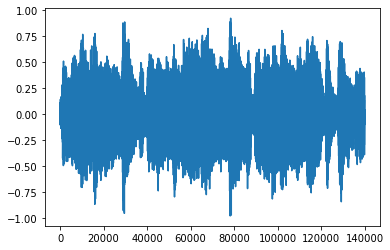

In [18]:
#Declipped audio plot
plt.plot(data_rec)

Below you can play the declipped audio.

In [19]:
ipd.Audio(data_rec, rate=fs)

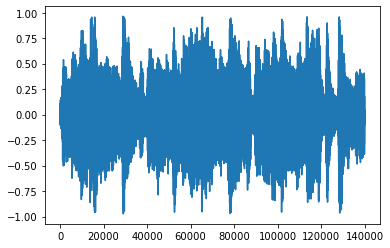

In [20]:
#Original audio plot 
plt.plot(data)

# Experiments

# Conclusions
In general, the task was quite difficult to perform, due to time constraints and lack o

# References
[1] Kai Siedenburg, Matthieu Kowalski, Monika Dörfler. Audio Declipping with Social Sparsity. IEEE
International Conference on Acoustics, Speech and Signal Processing (ICASSP 2014), May 2014,
Florence, Italy. pp.AASP-L2. hal-01002998